In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("mobile_game_inapp_purchases.csv")

np.random.seed(42)

df["ExperimentGroup"] = np.random.choice(
    ["Control", "Treatment"],
    size=len(df)
)

In [3]:
# comparing means

df.groupby("ExperimentGroup")[[
    "SessionCount",
    "AverageSessionLength",
    "InAppPurchaseAmount"
]].mean()

,SessionCount,AverageSessionLength,InAppPurchaseAmount
ExperimentGroup,,,
Control,10.089122,20.008480,108.290672
Treatment,10.060080,20.140701,96.763294


In [9]:
# t test for rev

from scipy.stats import ttest_ind

control = df[df["ExperimentGroup"]=="Control"]["InAppPurchaseAmount"]
treatment = df[df["ExperimentGroup"]=="Treatment"]["InAppPurchaseAmount"]

t_stat, p_value = ttest_ind(control, treatment, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: nan
P-Value: nan


In [5]:
# conversion rate test / proportion z-test

from statsmodels.stats.proportion import proportions_ztest

df["IsPayer"] = np.where(df["InAppPurchaseAmount"] > 0, 1, 0)

control_conv = df[df["ExperimentGroup"]=="Control"]["IsPayer"]
treatment_conv = df[df["ExperimentGroup"]=="Treatment"]["IsPayer"]

count = np.array([treatment_conv.sum(), control_conv.sum()])
nobs = np.array([len(treatment_conv), len(control_conv)])

z_stat, p_val = proportions_ztest(count, nobs)

print("Z-Stat:", z_stat)
print("P-Value:", p_val)

Z-Stat: -0.023480107340639732
P-Value: 0.981267306153284


In [7]:
# experiment decision

alpha = 0.05  # significance level

print("P-Value:", round(p_value, 5))
print("Revenue Lift (%):", round(lift, 2))

if p_value < alpha and lift > 0:
    print("\nDecision: SHIP FEATURE")
    print("Reason: Statistically significant improvement in revenue.")
    
elif p_value < alpha and lift < 0:
    print("\nDecision: DO NOT SHIP FEATURE")
    print("Reason: Statistically significant decline in revenue.")

else:
    print("\nDecision: INCONCLUSIVE TEST")
    print("Reason: Result not statistically significant.")
    print("Recommendation: Extend experiment duration or increase sample size.")

P-Value: nan
Revenue Lift (%): -10.64

Decision: INCONCLUSIVE TEST
Reason: Result not statistically significant.
Recommendation: Extend experiment duration or increase sample size.


In [11]:
# rev lift calculation

control_mean = control.mean()
treatment_mean = treatment.mean()

if control_mean != 0:
    lift = (treatment_mean - control_mean) / control_mean * 100
else:
    lift = 0

print("Revenue Lift (%):", round(lift,2))

Revenue Lift (%): -10.64


In [12]:
# improve experiment summary output

print("===== EXPERIMENT SUMMARY =====")

print("Control Avg Revenue:", round(control_mean,2))
print("Treatment Avg Revenue:", round(treatment_mean,2))

print("Revenue Lift (%):", round(lift,2))
print("P-Value:", round(p_value,5))

print("\nConversion Rates")
print("Control:", round(control_conv_rate,3))
print("Treatment:", round(treatment_conv_rate,3))

print("Conversion Lift (%):", round(conv_lift,2))
print("Z-Test P-Value:", round(p_val, 5))

===== EXPERIMENT SUMMARY =====
Control Avg Revenue: 108.29
Treatment Avg Revenue: 96.76
Revenue Lift (%): -10.64
P-Value: nan

Conversion Rates
Control: 0.955
Treatment: 0.955
Conversion Lift (%): -0.02
Z-Test P-Value: 0.98127


In [8]:
# conversion rate comparison
control_conv_rate = control_conv.mean()
treatment_conv_rate = treatment_conv.mean()

conv_lift = (treatment_conv_rate - control_conv_rate) / control_conv_rate * 100

print("\nConversion Lift (%):", round(conv_lift, 2))

if p_value < alpha and lift > 0 and conv_lift > 0:
    print("\nFinal Recommendation: SHIP FEATURE")
    print("Feature improves both revenue and payer conversion.")

elif p_value < alpha and lift > 0:
    print("\nFinal Recommendation: CONDITIONAL SHIP")
    print("Revenue improved but conversion impact unclear.")

else:
    print("\nFinal Recommendation: DO NOT SHIP")
    print("No statistically significant improvement.")


Conversion Lift (%): -0.02

Final Recommendation: DO NOT SHIP
No statistically significant improvement.


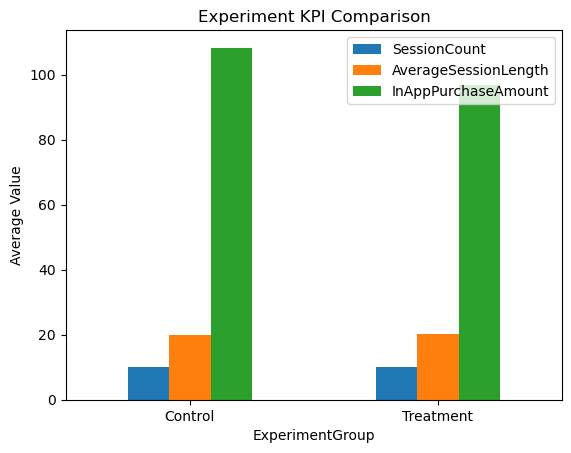

In [14]:
## visuals

import matplotlib.pyplot as plt

kpis = df.groupby("ExperimentGroup")[[
    "SessionCount",
    "AverageSessionLength",
    "InAppPurchaseAmount"
]].mean()

kpis.plot(kind="bar")

plt.title("Experiment KPI Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

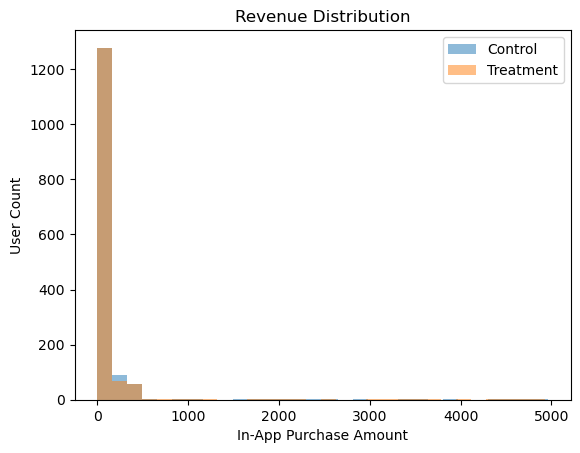

In [17]:
## rev distribution visual

plt.hist(control, bins=30, alpha=0.5, label="Control")
plt.hist(treatment, bins=30, alpha=0.5, label="Treatment")

plt.title("Revenue Distribution")
plt.xlabel("In-App Purchase Amount")
plt.ylabel("User Count")
plt.legend()

plt.show()

In [18]:
### experiment simulation note ###
# This analysis simulates an A/B experiement by randomly assigning users into control and treatment groups.
# In a real production environment, users would be assigned via an experimentation platform (ex: Optimizely, LaunchDarkly, or internal tool).
# The statistical testing and decision framework remain identical to real-world experimentation workflows.